# The five bills point in two directions

Among passengers with `CryoSleep` equal to `True`, scan every filled bill cell. The count of cells with a positive amount is 0. Cryosleep and a known positive bill do not occur together. Candra still has an empty `VRDeck`: empty is allowed, positive is not.

Among awake passengers, the three bills `RoomService`, `Spa`, and `VRDeck` move together. Call their sum the luxury bill, and use it only when all three cells are filled. The share transported falls as that sum rises.

$$
\begin{aligned}
0 &: 406 \text{ of } 638 \\
1 \text{ to } 499 &: 732 \text{ of } 1332 \\
500 \text{ to } 1999 &: 474 \text{ of } 2260 \\
2000 \text{ or more} &: 75 \text{ of } 872
\end{aligned}
$$

`FoodCourt` and `ShoppingMall`, counted alone on awake passengers, rise instead of fall. At 2000 or more, the food court is 323 of 530 and the shopping mall is 90 of 123.

Adding all five bills into one total mixes a falling pattern with a rising pattern. The luxury sum is the column the later rule uses. Juanna's luxury bill is $109 + 549 + 44 = 702$, so she sits in the 500 to 1999 band, where 474 of 2260 were transported.


In [2]:
# Locate the contest tables beside this notebook, or under the course root.
from pathlib import Path
import csv

def manifest_path(name):
    here = Path.cwd()
    for folder in [here, *here.parents]:
        nested = folder / "14-Spaceship Titanic" / "data" / name
        direct = folder / "data" / name
        if nested.exists():
            return nested
        if direct.exists() and (folder / "data" / "sample_submission.csv").exists():
            return direct
    raise FileNotFoundError(name)

def read_manifest(name):
    with manifest_path(name).open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))

train = read_manifest("train.csv")
test = read_manifest("test.csv")
submission = read_manifest("sample_submission.csv")
print(len(train), len(test), len(submission))
print(train[0]["PassengerId"], train[0]["Name"])


8693 4277 4277
0001_01 Maham Ofracculy


In [3]:
# Whole numbers are stored as decimals, such as 39.0.
def whole(text):
    return int(float(text))

def luxury(row):
    columns = ("RoomService", "Spa", "VRDeck")
    if any(row[column] == "" for column in columns):
        return None
    return sum(whole(row[column]) for column in columns)

def cryo_rule(row):
    return row["CryoSleep"] == "True"

def decision_list(row):
    # Step 1. Cryosleep.
    if row["CryoSleep"] == "True":
        return True
    # Step 2. Awake, and the luxury bill is at least 500.
    bill = luxury(row)
    if row["CryoSleep"] == "False" and bill is not None and bill >= 500:
        return False
    # Step 3. Age at most 12.
    if row["Age"] != "" and whole(row["Age"]) <= 12:
        return True
    # Step 4. Europa, deck B or deck C.
    if row["Cabin"] != "":
        deck = row["Cabin"].split("/")[0]
        if row["HomePlanet"] == "Europa" and deck in ("B", "C"):
            return True
    # Step 5. Everyone else stays.
    return False

print("rules ready", len(train))


rules ready 8693


In [4]:
# Positive cryosleep bills, then the awake luxury bands.
spend = ("RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck")
positive_cells = 0
for row in train:
    if row["CryoSleep"] != "True":
        continue
    for column in spend:
        if row[column] != "" and whole(row[column]) > 0:
            positive_cells += 1
print("positive cryosleep bill cells", positive_cells)
assert positive_cells == 0

def band(total):
    if total == 0:
        return "0"
    if total <= 499:
        return "1-499"
    if total <= 1999:
        return "500-1999"
    return "2000+"

bands = {name: [0, 0] for name in ("0", "1-499", "500-1999", "2000+")}
for row in train:
    if row["CryoSleep"] != "False":
        continue
    bill = luxury(row)
    if bill is None:
        continue
    stayed_or_moved = bands[band(bill)]
    stayed_or_moved[row["Transported"] == "True"] += 1
for name, (stayed, transported) in bands.items():
    print(name, transported, stayed + transported)
assert bands["0"] == [638 - 406, 406]
assert bands["1-499"] == [1332 - 732, 732]
assert bands["500-1999"] == [2260 - 474, 474]
assert bands["2000+"] == [872 - 75, 75]

def awake_high(column, low):
    transported = total = 0
    for row in train:
        if row["CryoSleep"] != "False" or row[column] == "":
            continue
        if whole(row[column]) >= low:
            total += 1
            transported += row["Transported"] == "True"
    return transported, total

print("FoodCourt", awake_high("FoodCourt", 2000))
print("ShoppingMall", awake_high("ShoppingMall", 2000))
assert awake_high("FoodCourt", 2000) == (323, 530)
assert awake_high("ShoppingMall", 2000) == (90, 123)


positive cryosleep bill cells 0
0 406 638
1-499 732 1332
500-1999 474 2260
2000+ 75 872
FoodCourt (323, 530)
ShoppingMall (90, 123)


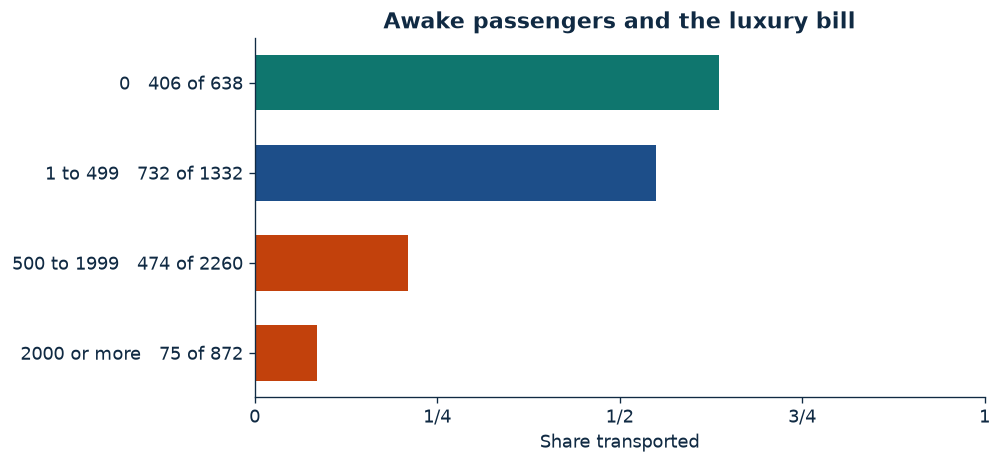

In [5]:
# The luxury bands, drawn from zero so the drop at 500 stays to scale.
import matplotlib.pyplot as plt
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#102a43",
    "axes.labelcolor": "#102a43",
    "xtick.color": "#102a43",
    "ytick.color": "#102a43",
    "text.color": "#102a43",
})
shares = [
    ("0", 406, 638, "#0f766e"),
    ("1 to 499", 732, 1332, "#1d4e89"),
    ("500 to 1999", 474, 2260, "#c2410c"),
    ("2000 or more", 75, 872, "#c2410c"),
]
figure, axis = plt.subplots(figsize=(8.6, 4.0))
positions = [3, 2, 1, 0]
axis.barh(
    positions,
    [transported / total for _, transported, total, _ in shares],
    color=[color for *_, color in shares],
    height=0.62,
)
axis.set_yticks(
    positions,
    [f"{name}   {transported} of {total}" for name, transported, total, _ in shares],
)
axis.set_xlim(0, 1)
axis.set_xticks([0, 0.25, 0.5, 0.75, 1])
axis.set_xticklabels(["0", "1/4", "1/2", "3/4", "1"])
axis.set_xlabel("Share transported")
axis.set_title("Awake passengers and the luxury bill")
figure.tight_layout()


## Pitfall

A single "total spend" adds the food court and the shopping mall to the three luxury bills. Those two columns are higher, not lower, when the bill is large. The sum then hides the drop that the luxury bill shows between 499 and 500.

## Summary

Cryosleep rows contain no known positive bill. For awake passengers the luxury total 0 is 406 of 638 transported, and 2000 or more is 75 of 872.
